<a href="https://colab.research.google.com/github/nuvoledicaffe/Deep-Learning-Project/blob/main/bound.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


>>> Analisi con Weight Decay (lambda) = 0.0001
   Stat. Gradiente: 0.003606
   MSE Reale: 0.00005801 | Bound Teorico: 2.21151342

>>> Analisi con Weight Decay (lambda) = 0.0005
   Stat. Gradiente: 0.003588
   MSE Reale: 0.00005351 | Bound Teorico: 0.08758181

>>> Analisi con Weight Decay (lambda) = 0.001
   Stat. Gradiente: 0.003534
   MSE Reale: 0.00004831 | Bound Teorico: 0.02123839

>>> Analisi con Weight Decay (lambda) = 0.005
   Stat. Gradiente: 0.003502
   MSE Reale: 0.00002132 | Bound Teorico: 0.00083424

>>> Analisi con Weight Decay (lambda) = 0.01
   Stat. Gradiente: 0.003481
   MSE Reale: 0.00000898 | Bound Teorico: 0.00020608

>>> Analisi con Weight Decay (lambda) = 0.05
   Stat. Gradiente: 0.003934
   MSE Reale: 0.00000389 | Bound Teorico: 0.00001053


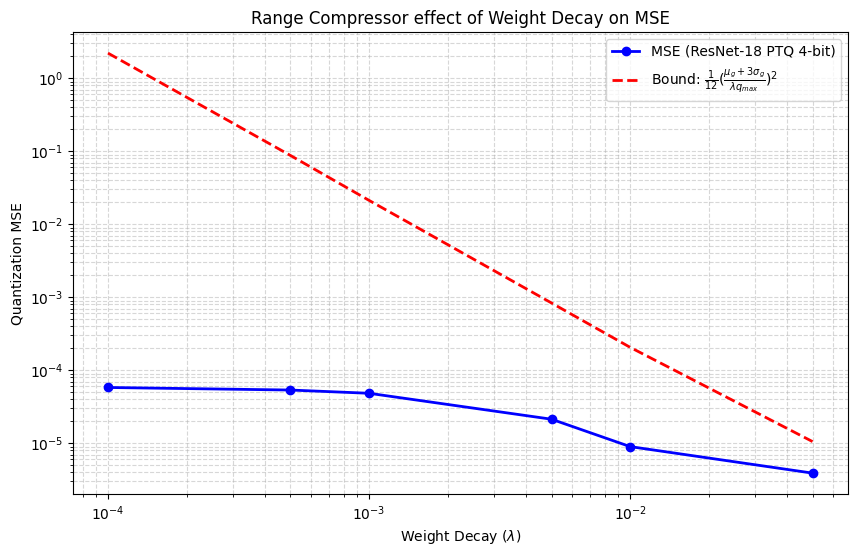

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import copy
import numpy as np

# 1. DEVICE SETUP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. DATALOADERS (CIFAR10)
def get_dataloaders(batch_size=128):
    cpu_transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=cpu_transform)
    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    return train_loader

# 3. RESNET-18 MODEL
def get_model():
    model = torchvision.models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)

# 4. UNIFORM QUANTIZATION WITH STATISTICAL CLIPPING (99.9%)
def apply_quantization_with_clipping(model, bits=4, percentile=99.9):
    q_model = copy.deepcopy(model).cpu()
    q_max = 7  # q_max for 4-bit
    q_min = -8 # q_min for 4-bit

    with torch.no_grad():
        for param in q_model.parameters():
            if param.ndimension() > 1:
                # Calculate alpha (clipping threshold) based on the empirical percentile
                flat_param = param.abs().view(-1)
                alpha = np.percentile(flat_param.numpy(), percentile)

                # Scaling factor S based on the compressed distribution
                scale = alpha / q_max if alpha > 0 else 1e-8
                param.copy_(torch.round(param / scale).clamp(q_min, q_max) * scale)
    return q_model.to(device)

# 5. EXPERIMENT WITH GRADIENT STATISTICS AND EVOLVED BOUND
def run_statistical_analysis(values, epochs=3):
    train_loader = get_dataloaders()
    criterion = nn.CrossEntropyLoss()
    q_max = 7
    results = []

    for wd in values:
        print(f"\n>>> Analysis with Weight Decay (lambda) = {wd}")
        model = get_model()
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=wd)

        # Accumulators for gradient statistics
        grad_means = []
        grad_stds = []

        for epoch in range(epochs):
            model.train()
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()

                # Extract gradient statistics for this batch
                with torch.no_grad():
                    all_grads = []
                    for p in model.parameters():
                        if p.grad is not None:
                            all_grads.append(p.grad.abs().view(-1))

                    if all_grads:
                        step_grads = torch.cat(all_grads)
                        grad_means.append(torch.mean(step_grads).item())
                        grad_stds.append(torch.std(step_grads).item())

                optimizer.step()

        # Calculate Statistical Gradient (Mean + 3*Sigma) during training
        # This represents the typical force opposing lambda
        statistical_grad = np.mean(grad_means) + 3 * np.mean(grad_stds)

        # Quantization and actual MSE calculation
        q_model = apply_quantization_with_clipping(model, bits=4, percentile=99.9)
        mse_total, count = 0, 0
        for p1, p2 in zip(model.parameters(), q_model.parameters()):
            if p1.ndimension() > 1:
                mse_total += torch.mean((p1 - p2)**2).item()
                count += 1
        avg_mse = mse_total / count

        # --- NEW THEORETICAL BOUND CALCULATION (14) ---
        # MSE <= (1/12) * ( (mu_grad + 3*sigma_grad) / (lambda * q_max) )^2
        theoretical_bound = (1/12) * (statistical_grad / (wd * q_max))**2 if wd > 0 else float('inf')

        results.append({
            'wd': wd,
            'mse': avg_mse,
            'bound': theoretical_bound,
            'grad_stat': statistical_grad
        })
        print(f"   Stat. Gradient: {statistical_grad:.6f}")
        print(f"   Actual MSE: {avg_mse:.8f} | Theoretical Bound: {theoretical_bound:.8f}")

    return results

# 6. PLOT RESULTS
def plot_results(results):
    wd_vals = [r['wd'] for r in results]
    mse_vals = [r['mse'] for r in results]
    bound_vals = [r['bound'] for r in results]

    plt.figure(figsize=(10, 6))
    plt.plot(wd_vals, mse_vals, 'b-o', linewidth=2, label='MSE (ResNet-18 PTQ 4-bit)')
    plt.plot(wd_vals, bound_vals, 'r--', linewidth=2, label=r'Bound: $\frac{1}{12}(\frac{\mu_{g} + 3\sigma_{g}}{\lambda q_{max}})^2$')

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'Weight Decay ($\lambda$)')
    plt.ylabel('Quantization MSE')
    plt.title('Range Compressor effect of Weight Decay on MSE')
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    # Test a significant range of lambda values
    wd_test_values = [1e-3, 3e-3, 5e-3, 8e-3, 1e-2, 5e-2]
    res = run_statistical_analysis(wd_test_values, epochs=3)
    plot_results(res)